In [2]:
#import the librarys
#======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#load the date
df = pd.read_csv(r"D:\Project (Navodita infotech)\Customer Segmentation Analysis-[Rohit Kumar Prajapati]\train.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



======================data exploration===================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB

======================Customer Age Distribution======================



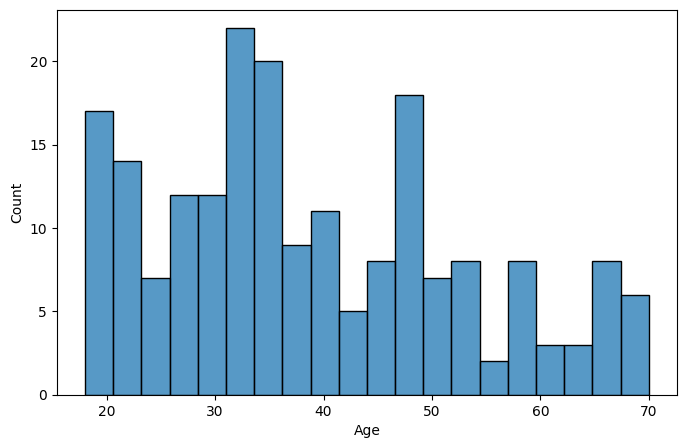


===============================Gender Distribution=============================



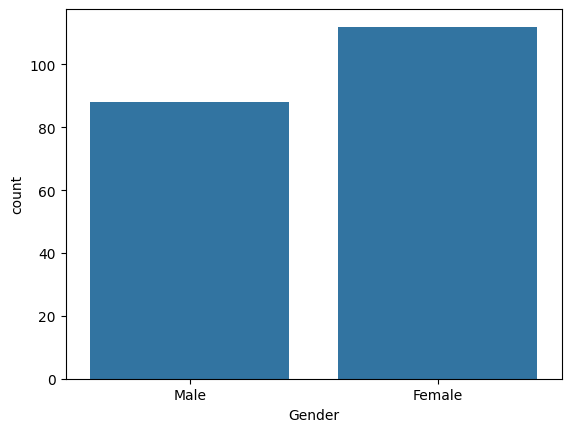


===========================Annual Income Distribution========================



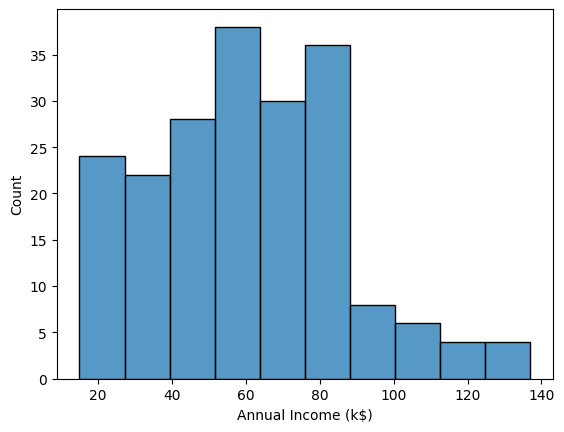


===========================Spending Score Distribution========================



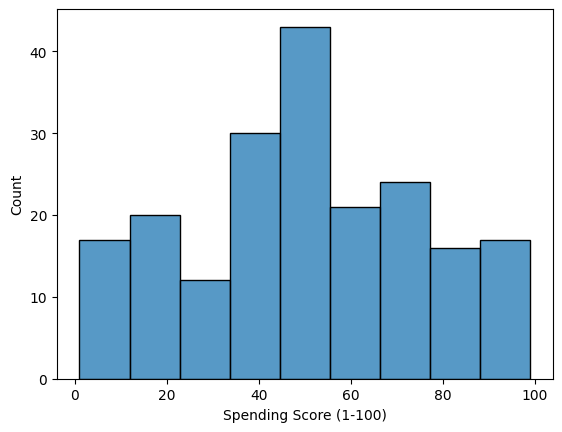


===========================Correlation Heatmap========================



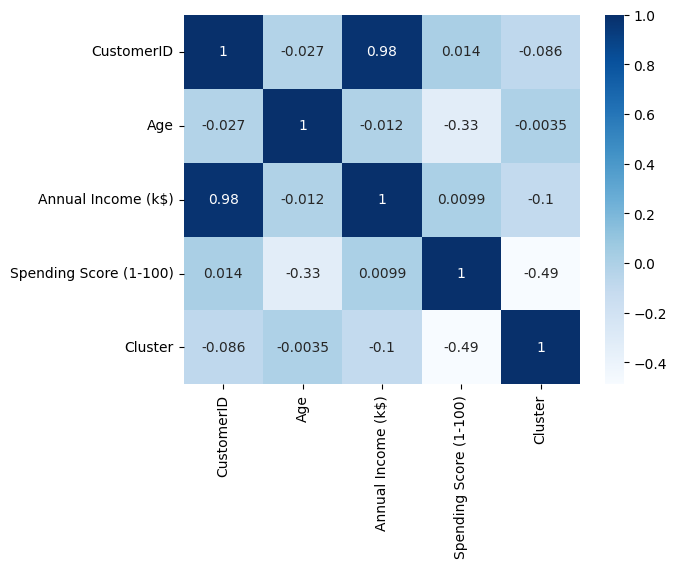


===========================Feature Selection========================


Use only Annual Income, Spending Score

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]

=========================Find Best Number of Clusters (Elbow Method)====================



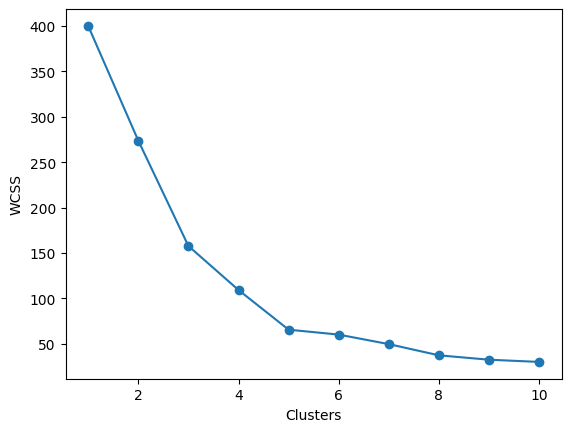


==================================Visualize Customer Segments=============================



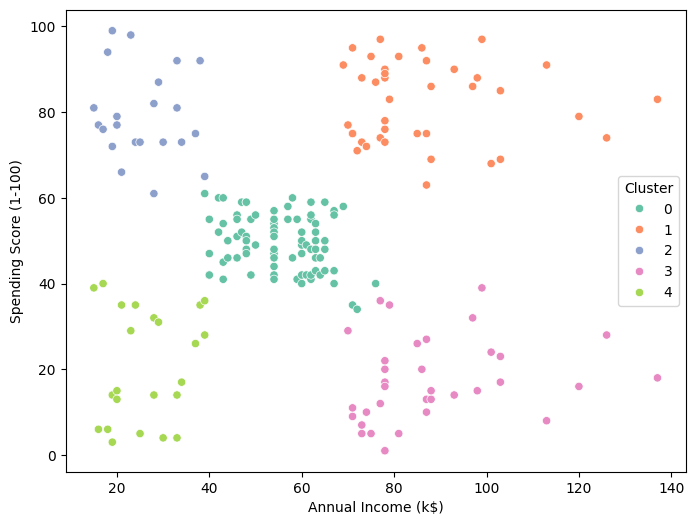


=========================================PCA Visualization===========================================



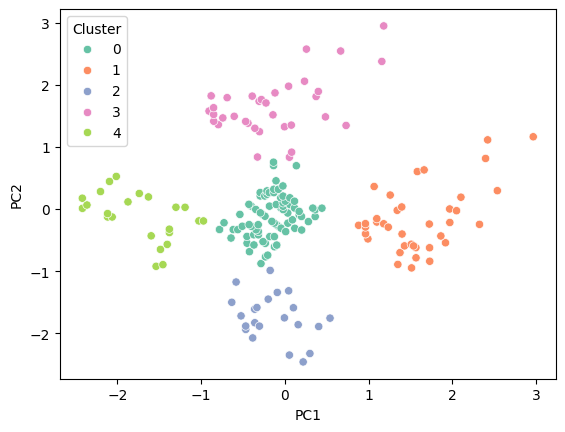

In [16]:
#data exploration

print("\n======================data exploration===================\n")
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

#Exploratory Data Analysis (EDA)
#Customer Age Distribution

print("\n======================Customer Age Distribution======================\n")
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.show()

#Gender Distribution

print("\n===============================Gender Distribution=============================\n")
sns.countplot(data=df,x="Gender")
plt.show()

#Annual Income Distribution
print("\n===========================Annual Income Distribution========================\n")
sns.histplot(df["Annual Income (k$)"])
plt.show()

#Spending Score Distribution
print("\n===========================Spending Score Distribution========================\n")
sns.histplot(df["Spending Score (1-100)"])
plt.show()

#Correlation Heatmap
print("\n===========================Correlation Heatmap========================\n")
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.show()

#Feature Selection
print("\n===========================Feature Selection========================\n")
print("\nUse only Annual Income, Spending Score\n")

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]
print(X)

#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Find Best Number of Clusters (Elbow Method)
print("\n=========================Find Best Number of Clusters (Elbow Method)====================\n")
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i,
                 random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

#Train K-Means Model
kmeans=KMeans(n_clusters=5,
              random_state=42)
df["Cluster"]=kmeans.fit_predict(X_scaled)

#Visualize Customer Segments
print("\n==================================Visualize Customer Segments=============================\n")
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2"
)
plt.show()

#PCA Visualization
print("\n=========================================PCA Visualization===========================================\n")
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)
df["PC1"]=pca_data[:,0]
df["PC2"]=pca_data[:,1]
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)
plt.show()






